<a href="https://colab.research.google.com/github/EdithYounes/ASD_Gene_Analysis/blob/main/ASD_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11-Mar-2026 07:30:40 DEBUG utils - Directory ./ already exists. Skipping.
DEBUG:GEOparse:Directory ./ already exists. Skipping.
11-Mar-2026 07:30:40 INFO GEOparse - File already exist: using local version.
INFO:GEOparse:File already exist: using local version.
11-Mar-2026 07:30:40 INFO GEOparse - Parsing ./GSE18123_family.soft.gz: 
INFO:GEOparse:Parsing ./GSE18123_family.soft.gz: 
11-Mar-2026 07:30:40 DEBUG GEOparse - DATABASE: GeoMiame
DEBUG:GEOparse:DATABASE: GeoMiame
11-Mar-2026 07:30:40 DEBUG GEOparse - SERIES: GSE18123
DEBUG:GEOparse:SERIES: GSE18123
11-Mar-2026 07:30:40 DEBUG GEOparse - PLATFORM: GPL570
DEBUG:GEOparse:PLATFORM: GPL570
/usr/local/lib/python3.12/dist-packages/GEOparse/GEOparse.py:401: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  return read_csv(StringIO(data), index_col=None, sep="\t")
11-Mar-2026 07:30:42 DEBUG GEOparse - PLATFORM: GPL6244
DEBUG:GEOparse:PLATFORM: GPL6244
11-Mar-2026 07:30:45 DEBUG GEOparse 

Label distribution:
0    213
1     72
Name: count, dtype: int64
Samples: 285
Genes: 5000


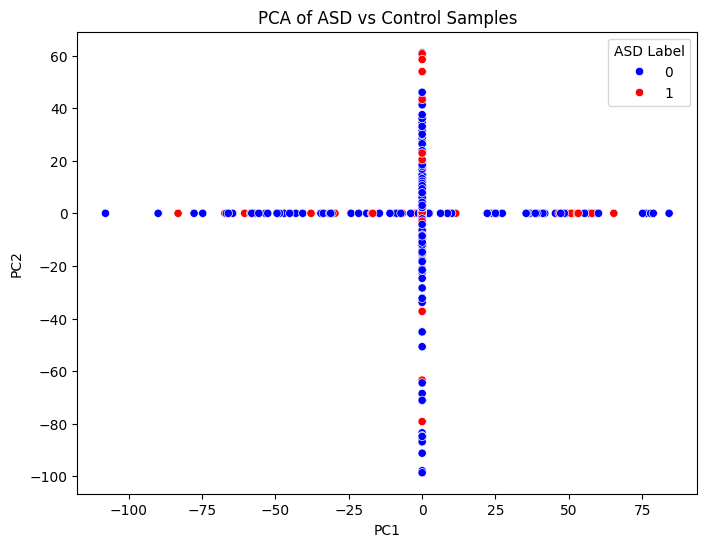

Train Accuracy: 1.0
Test Accuracy: 0.7543859649122807


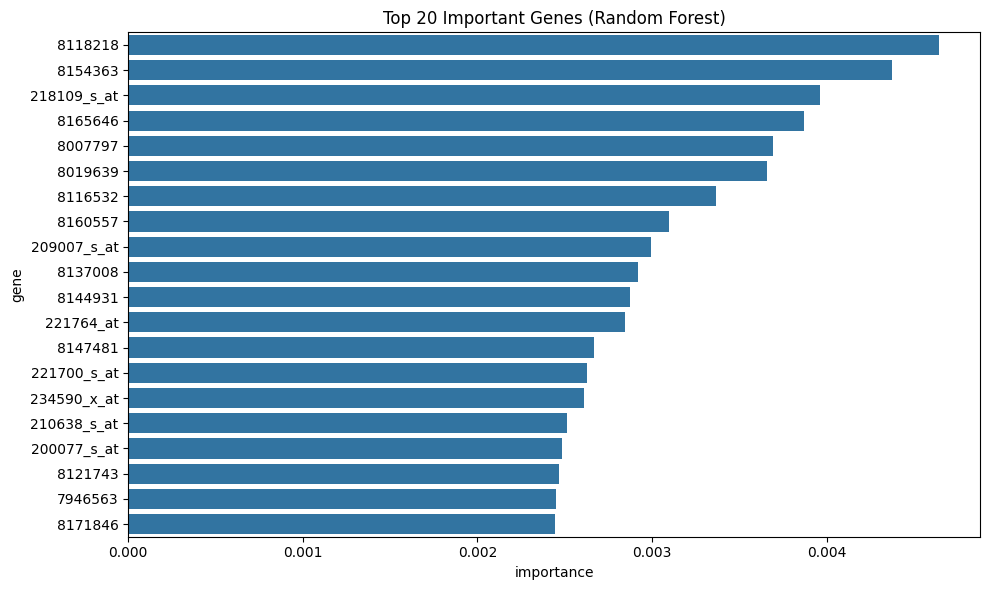

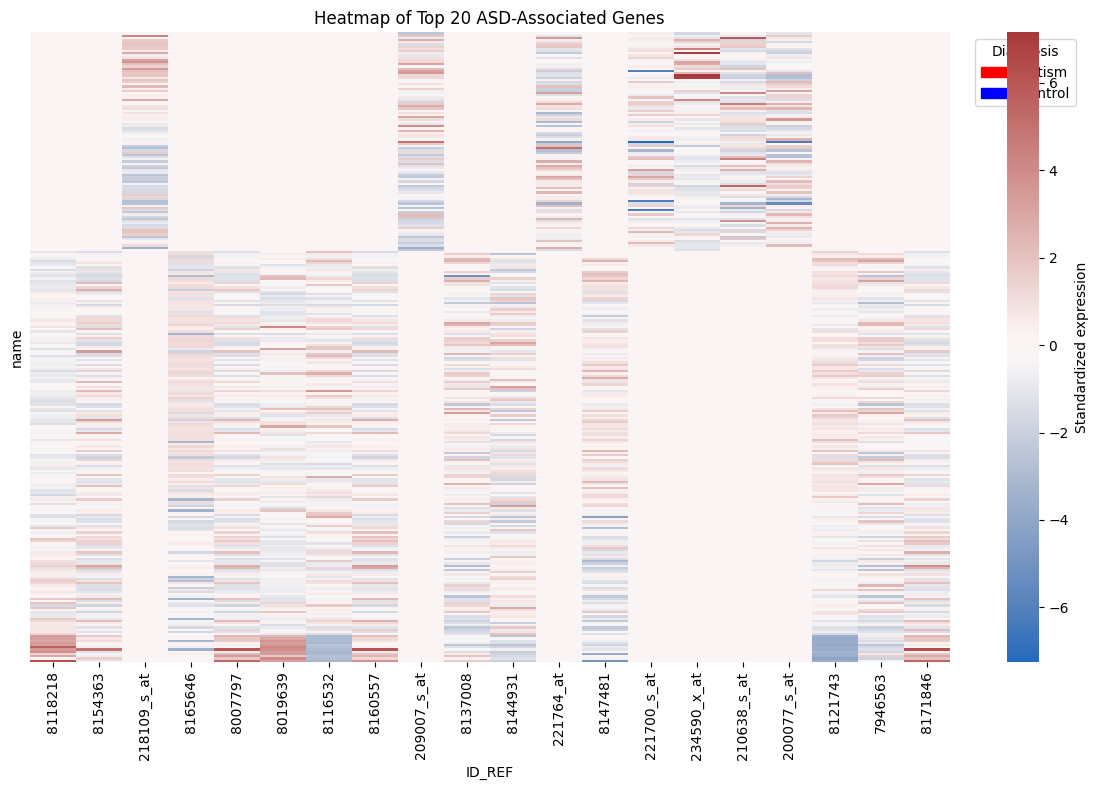

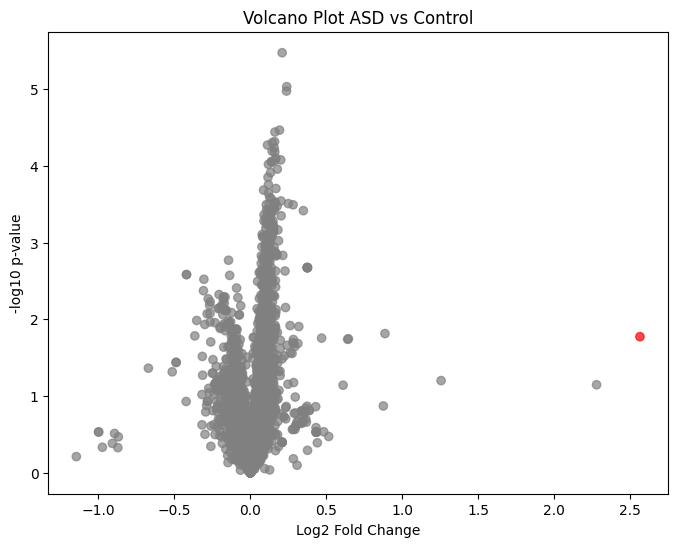


Candidate genes:
Empty DataFrame
Columns: [Gene, ML_Importance]
Index: []

✅ All figures generated:
- PCA plot
- Feature importance plot
- Heatmap of top genes
- Volcano plot


In [3]:
# ===== 1️⃣ Install GEOparse =====
!pip install GEOparse --quiet

# ===== 2️⃣ Imports =====
import GEOparse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from scipy.stats import ttest_ind

# ===== 3️⃣ Download GEO dataset =====
gse = GEOparse.get_GEO("GSE18123", destdir="./")

# Expression matrix (genes x samples)
expr = gse.pivot_samples('VALUE')

# ===== 4️⃣ Extract Metadata =====
metadata = {gsm: gse.gsms[gsm].metadata for gsm in gse.gsms}
metadata = pd.DataFrame.from_dict(metadata, orient='index')

# Convert list metadata to string
metadata['characteristics_clean'] = metadata['characteristics_ch1'].apply(
    lambda x: str(x).lower()
)

# Create labels
# 1 = Autism, 0 = Control
y = metadata['characteristics_clean'].apply(
    lambda x: 1 if 'autism' in x else 0
).values

print("Label distribution:")
print(pd.Series(y).value_counts())

# ===== 5️⃣ Handle Missing Gene Values =====
expr_clean = expr.apply(lambda row: row.fillna(row.mean()), axis=1)

# ===== 6️⃣ Select Most Variable Genes =====
gene_variance = expr_clean.var(axis=1)

top_genes = gene_variance.sort_values(ascending=False).head(5000).index
expr_filtered = expr_clean.loc[top_genes]

# ===== 7️⃣ Prepare ML Matrix =====
X = expr_filtered.T
X.columns = X.columns.astype(str)

print("Samples:", X.shape[0])
print("Genes:", X.shape[1])

# ===== 8️⃣ Standardize Features =====
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ===== 9️⃣ PCA Visualization =====
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette=["blue","red"])

plt.title("PCA of ASD vs Control Samples")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="ASD Label")

plt.savefig("pca_autism_samples.png")
plt.show()

# ===== 🔟 Random Forest Classification =====
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print("Train Accuracy:", rf.score(X_train, y_train))
print("Test Accuracy:", rf.score(X_test, y_test))

# ===== 1️⃣1️⃣ Feature Importance =====
importances = rf.feature_importances_

feature_importance = pd.DataFrame({
    "gene": expr_filtered.index,
    "importance": importances
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(
    x="importance",
    y="gene",
    data=feature_importance.head(20)
)

plt.title("Top 20 Important Genes (Random Forest)")
plt.tight_layout()

plt.savefig("feature_importance_genes.png")
plt.show()

# ===== 1️⃣2️⃣ Heatmap of Top 20 Genes =====
import matplotlib.patches as mpatches

top20_genes = feature_importance.head(20)['gene'].astype(str).values

heatmap_data = X[top20_genes]

# Standardize per gene
heatmap_data = (heatmap_data - heatmap_data.mean()) / heatmap_data.std()

row_colors = np.array(['red' if label==1 else 'blue' for label in y])

plt.figure(figsize=(12,8))

sns.heatmap(
    heatmap_data,
    cmap="vlag",
    yticklabels=False,
    cbar_kws={'label': 'Standardized expression'}
)

red_patch = mpatches.Patch(color='red', label='Autism')
blue_patch = mpatches.Patch(color='blue', label='Control')

plt.legend(
    handles=[red_patch, blue_patch],
    bbox_to_anchor=(1.02,1),
    loc='upper left',
    title="Diagnosis"
)

plt.title("Heatmap of Top 20 ASD-Associated Genes")
plt.tight_layout()

plt.savefig("top20_genes_heatmap.png")
plt.show()

# ===== 1️⃣3️⃣ Volcano Plot =====
group_asd = X.values[y==1]
group_control = X.values[y==0]

logFC = np.log2(group_asd.mean(axis=0)+1e-6) - np.log2(group_control.mean(axis=0)+1e-6)

pvals = np.array([
    ttest_ind(group_asd[:,i], group_control[:,i])[1]
    for i in range(X.shape[1])
])

neg_log_p = -np.log10(pvals + 1e-10)

plt.figure(figsize=(8,6))

plt.scatter(
    logFC,
    neg_log_p,
    c=['red' if (abs(fc)>1 and p<0.05) else 'grey' for fc,p in zip(logFC,pvals)],
    alpha=0.7
)

plt.xlabel("Log2 Fold Change")
plt.ylabel("-log10 p-value")
plt.title("Volcano Plot ASD vs Control")

plt.savefig("volcano_plot_autism.png")
plt.show()

# ===== 1️⃣4️⃣ Candidate Gene Detection =====
top_genes_ml = feature_importance.head(5)["gene"].values
top_genes_pval = np.array(expr_filtered.index)[np.argsort(pvals)[:5]]

candidate_genes = set(top_genes_ml) & set(top_genes_pval)

candidate_table = pd.DataFrame({
    "Gene": list(candidate_genes),
    "ML_Importance": feature_importance.set_index('gene').loc[list(candidate_genes)]['importance']
})

print("\nCandidate genes:")
print(candidate_table)

print("\n✅ All figures generated:")
print("- PCA plot")
print("- Feature importance plot")
print("- Heatmap of top genes")
print("- Volcano plot")

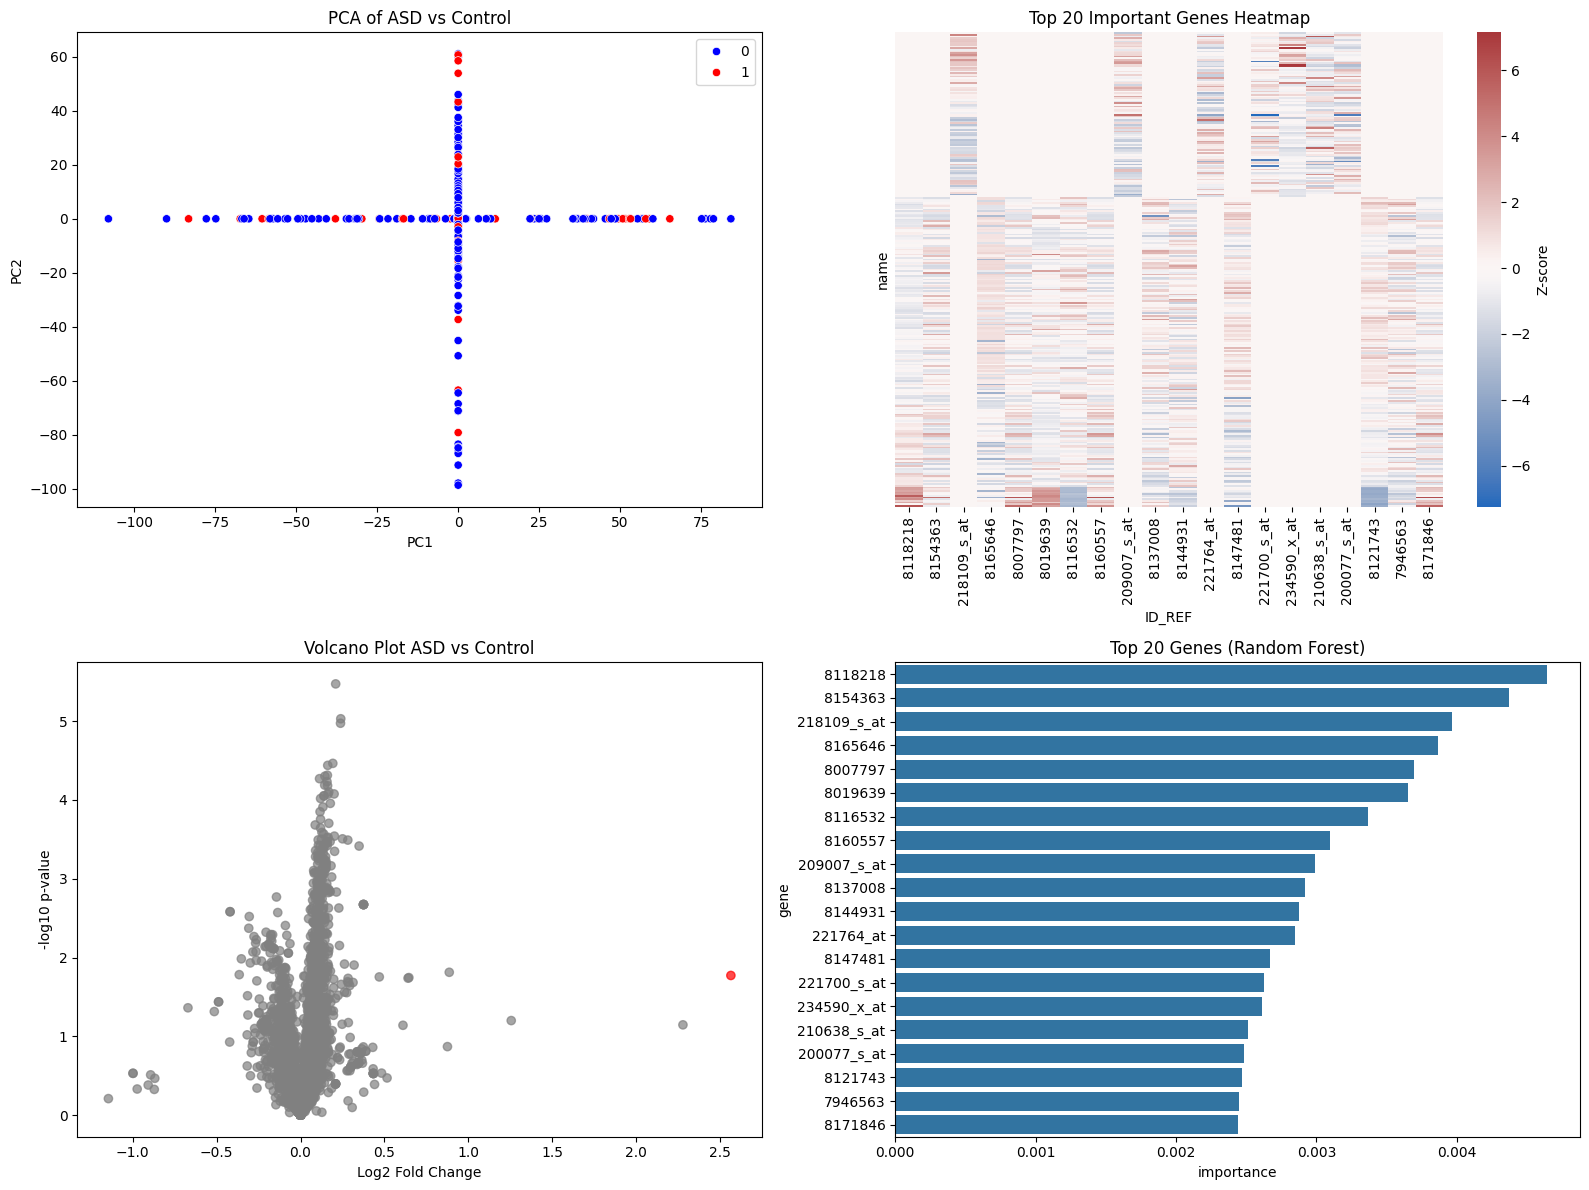

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---- Prepare Data ----
# PCA
X_pca = PCA(n_components=2).fit_transform(X_scaled)

# Heatmap data (top 20 RF genes)
top20_genes = feature_importance.head(20)['gene'].astype(str).values
heatmap_data = X[top20_genes]
heatmap_data = (heatmap_data - heatmap_data.mean()) / heatmap_data.std()
row_colors = np.array(['red' if label==1 else 'blue' for label in y])

# Volcano plot data
logFC = np.log2(X.values[y==1].mean(axis=0)+1e-6) - np.log2(X.values[y==0].mean(axis=0)+1e-6)
pvals = np.array([ttest_ind(X.values[y==1][:,i], X.values[y==0][:,i])[1] for i in range(X.shape[1])])
neg_log_p = -np.log10(pvals + 1e-10)

# ---- Create Figure ----
fig, axes = plt.subplots(2, 2, figsize=(16,12))

# PCA
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette=["blue","red"], ax=axes[0,0])
axes[0,0].set_title("PCA of ASD vs Control")
axes[0,0].set_xlabel("PC1")
axes[0,0].set_ylabel("PC2")

# Heatmap
sns.heatmap(heatmap_data, cmap="vlag", yticklabels=False, cbar_kws={'label': 'Z-score'}, ax=axes[0,1])
axes[0,1].set_title("Top 20 Important Genes Heatmap")

# Volcano
axes[1,0].scatter(logFC, neg_log_p, c=['red' if (abs(fc)>1 and p<0.05) else 'grey' for fc,p in zip(logFC,pvals)], alpha=0.7)
axes[1,0].set_xlabel("Log2 Fold Change")
axes[1,0].set_ylabel("-log10 p-value")
axes[1,0].set_title("Volcano Plot ASD vs Control")

# Top RF genes bar plot
sns.barplot(x="importance", y="gene", data=feature_importance.head(20), ax=axes[1,1])
axes[1,1].set_title("Top 20 Genes (Random Forest)")

plt.tight_layout()
plt.savefig("summary_figure_all_panels.png", dpi=300)
plt.show()